In [3]:
import os
import argparse
from types import SimpleNamespace
from pathlib import Path

import nilearn
from nilearn import plotting, datasets

import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, Normalize, BoundaryNorm
from matplotlib.patches import Patch
from mpl_toolkits.mplot3d.art3d import Line3DCollection

os.chdir("/engram/nklab/pf2477/brain_decoding/")
from brain_adapter.dataset import nsd_topk_parcel_dataset, get_dominant_roi_per_parcel

In [4]:
subj=1
args = SimpleNamespace(
        subj=subj,
        backbone_arch="dinov2_q",
        data_dir="/engram/nklab/datasets/natural_scene_dataset/model_training_datasets/neural_data",
        imgs_dir="/engram/nklab/datasets/natural_scene_dataset/nsddata_stimuli/stimuli/nsd",
        parcel_dir="/engram/nklab/algonauts/ethan/whole_brain_encoder/parcels/schaefer",
        hemi=None,
)
args.tokenizer = None
args.gen_size = 512
args.topk = 100
print("Setting up test configuration for subject ", subj)

print("\n" + "="*50)
print("Testing nsd_topk_parcel_dataset (single subject)")
print("="*50)
train_dataset = nsd_topk_parcel_dataset(args, split='train', transform=None, topk=args.topk)
print(len(train_dataset), "samples in the dataset")
print(train_dataset.selected_parcel_idx)
print(len(train_dataset.selected_parcel_idx['lh']), "left hemisphere parcels")
print(len(train_dataset.selected_parcel_idx['rh']), "right hemisphere parcels")

data = train_dataset[0]
print()
print("\nOutput shapes:")
print(f"img_encoder: {data['img_encoder'].shape}")
print(f"img_ipadapter: {data['img_ipadapter'].shape}")
print(f"brain_lh_f: {data['brain_lh_f'].shape}")
print(f"brain_rh_f: {data['brain_rh_f'].shape}")

Setting up test configuration for subject  1

Testing nsd_topk_parcel_dataset (single subject)
Training on subject: 1
9000 samples in the dataset
{'lh': array([  2,  21,  26,  27,  11,   0,   1, 157,   3, 158,  45,  24, 160,
        22,   9,  14, 151,  41,  20,  28,  18, 161,  15, 475,  32, 473,
         8, 159,  23, 163,  31,  17,  25, 166,  44, 164,  19, 467,  10,
       181,  29,  47, 155,   6, 154, 469, 156,   5,  12, 210, 476, 162,
        13, 170,  16, 167,  30,  33, 477,   7, 493, 370, 468, 369, 149,
        56, 377, 367,  46, 171, 213, 165, 172,   4, 153, 481, 495, 152,
       435, 182, 186, 323, 497, 174, 173, 358, 150, 482, 237, 471, 474,
        52, 247, 198, 483, 396, 325, 271, 184, 196]), 'rh': array([ 35,  39,  21,  10, 153,  37, 155,   2,  23,   4,   0, 154,  20,
       152,  42,  19, 151,  15,  36,   8, 302,  13,  43,  28,  41,  29,
       308,  17,  25, 147,   9,  24,  18, 390, 424,  14, 496,   1,  49,
        40, 162, 161, 305, 453, 389,  16, 333, 163, 175,  31, 149, 

In [5]:
neural_data_path = Path(
        "/engram/nklab/datasets/natural_scene_dataset/model_training_datasets/neural_data"
    )
metadata = np.load(
    neural_data_path / f"metadata_sub-{subj:02}.npy", allow_pickle=True
).item()

all_roi_names = list(metadata['lh_rois'].keys())[:24] + list(metadata['rh_rois'].keys())[:24]
print(f' all_roi_names: {all_roi_names}, len: {len(all_roi_names)}')

roi = all_roi_names[0]
print(metadata['lh_rois'][roi])
print(len(metadata['lh_rois'][roi]))
# print([id for id, val in enumerate(metadata['lh_rois'][roi]) if val == True])

min_overlap_threshold = 0.5
dominant_rois = get_dominant_roi_per_parcel(train_dataset, metadata, all_roi_names, min_overlap_threshold=min_overlap_threshold)

print("\n" + "="*50)
print("DOMINANT ROI PER PARCEL (>10% overlap)")
print("="*50)

for hemi in ['lh', 'rh']:
    print(f"\n{hemi.upper()} Hemisphere:")
    cnt = 0
    for parcel_idx, roi_name, overlap, num_voxels in dominant_rois[hemi]:
        if roi_name:
            print(f"Parcel {parcel_idx:3d}: {roi_name:20s} ({overlap:.1%}) in {num_voxels} Schaefer voxels")
            cnt += 1
        else:
            print(f"Parcel {parcel_idx:3d}: No ROI has >= {min_overlap_threshold:.1%} overlap")

    print(f"Total parcels with dominant ROI in {hemi.upper()}: {cnt}")

 all_roi_names: ['V1v', 'V1d', 'V2v', 'V2d', 'V3v', 'V3d', 'hV4', 'EBA', 'FBA-1', 'FBA-2', 'mTL-bodies', 'OFA', 'FFA-1', 'FFA-2', 'mTL-faces', 'aTL-faces', 'OPA', 'PPA', 'RSC', 'OWFA', 'VWFA-1', 'VWFA-2', 'mfs-words', 'mTL-words', 'V1v', 'V1d', 'V2v', 'V2d', 'V3v', 'V3d', 'hV4', 'EBA', 'FBA-1', 'FBA-2', 'mTL-bodies', 'OFA', 'FFA-1', 'FFA-2', 'mTL-faces', 'aTL-faces', 'OPA', 'PPA', 'RSC', 'OWFA', 'VWFA-1', 'VWFA-2', 'mfs-words', 'mTL-words'], len: 48
[False False False ... False False False]
163842
Processing 100 LH parcels with matrix operations...


LH:   0%|          | 0/100 [00:00<?, ?it/s]

LH: 100%|██████████| 100/100 [00:00<00:00, 258.27it/s]


Processing 100 RH parcels with matrix operations...


RH: 100%|██████████| 100/100 [00:00<00:00, 263.05it/s]


DOMINANT ROI PER PARCEL (>10% overlap)

LH Hemisphere:
Parcel   2: V1d                  (67.9%) in 184 Schaefer voxels
Parcel  21: EBA                  (100.0%) in 293 Schaefer voxels
Parcel  26: V2d                  (81.8%) in 192 Schaefer voxels
Parcel  27: V3d                  (52.0%) in 204 Schaefer voxels
Parcel  11: V2v                  (55.4%) in 408 Schaefer voxels
Parcel   0: V1v                  (55.0%) in 318 Schaefer voxels
Parcel   1: V1v                  (87.1%) in 233 Schaefer voxels
Parcel 157: EBA                  (95.5%) in 336 Schaefer voxels
Parcel   3: V1d                  (100.0%) in 241 Schaefer voxels
Parcel 158: EBA                  (100.0%) in 85 Schaefer voxels
Parcel  45: PPA                  (100.0%) in 381 Schaefer voxels
Parcel  24: V3d                  (54.0%) in 326 Schaefer voxels
Parcel 160: EBA                  (91.5%) in 201 Schaefer voxels
Parcel  22: V1d                  (69.3%) in 218 Schaefer voxels
Parcel   9: No ROI has >= 50.0% overlap
Parce

In [26]:
def plot_schaefer_by_roi_nilearn(dataset, metadata, dominant_rois, all_roi_names,
                                 unlabeled_name="(unlabeled)", unlabeled_color=(0.7,0.7,0.7,1.0),
                                 mesh="fsaverage", view="lateral", darkness=0.5):
    """
    dataset: nsd_topk_parcel_dataset or nsd_groupwise_topk_parcel_dataset (single-subject view)
    metadata: dict with 'lh_rois' and 'rh_rois' (per-vertex boolean arrays)
    dominant_rois: output of get_dominant_roi_per_parcel(...)
    all_roi_names: list of ROI names you passed into the function above
    """
    # ROI→index (0 reserved for unlabeled)
    roi_list = [unlabeled_name] + all_roi_names
    roi_to_idx = {name: i for i, name in enumerate(roi_list)}

    # Hemisphere sizes (should be 163,842 for fsaverage)
    lh_n = len(next(iter(metadata["lh_rois"].values())))
    rh_n = len(next(iter(metadata["rh_rois"].values())))

    # Init per-vertex label arrays
    lh_labels = np.zeros(lh_n, dtype=np.int32)
    rh_labels = np.zeros(rh_n, dtype=np.int32)

    # Parcel voxel indices (per selected parcel)
    sel_vox = dataset.get_selected_voxel_indices()  # {'lh': [tensor(...), ...], 'rh': [...]}

    # Paint each selected parcel with its dominant ROI label; leave 0 if none
    for hemi, labels, dom in [("lh", lh_labels, dominant_rois["lh"]),
                              ("rh", rh_labels, dominant_rois["rh"])]:
        for pos, (_orig_idx, roi_name, _overlap, _nvox) in enumerate(dom):
            vox = sel_vox[hemi][pos]
            vox = vox.cpu().numpy() if isinstance(vox, torch.Tensor) else np.asarray(vox)
            if vox.size == 0:
                continue
            labels[vox] = roi_to_idx.get(roi_name, 0) if roi_name is not None else 0

    # Discrete colormap: index 0 gray, others distinct
    base = plt.cm.tab20(np.linspace(0, 1, 20))
    need = max(1, len(roi_list) - 1)
    palette = np.vstack([base[1:],] * int(np.ceil(need / 19)))[:need]
    cmap = ListedColormap(np.vstack([np.array(unlabeled_color)[None, :], palette]))

    # Load fsaverage surfaces
    fsavg = datasets.fetch_surf_fsaverage(mesh=mesh)
    surfL, bgL = (fsavg.infl_left, fsavg.sulc_left) if hasattr(fsavg, "infl_left") else (fsavg.pial_left, fsavg.sulc_left)
    surfR, bgR = (fsavg.infl_right, fsavg.sulc_right) if hasattr(fsavg, "infl_right") else (fsavg.pial_right, fsavg.sulc_right)

    # Plot static figures
    fig = plt.figure(figsize=(10, 4))
    ax1 = fig.add_subplot(1, 2, 1, projection="3d")
    plotting.plot_surf(surfL, lh_labels, bg_map=bgL, hemi="left", view=view,
                       cmap=cmap, vmin=0, vmax=len(roi_list)-1, bg_on_data=True,
                       darkness=darkness, colorbar=False, axes=ax1)
    ax1.set_title("Left hemisphere")

    ax2 = fig.add_subplot(1, 2, 2, projection="3d")
    plotting.plot_surf(surfR, rh_labels, bg_map=bgR, hemi="right", view=view,
                       cmap=cmap, vmin=0, vmax=len(roi_list)-1, bg_on_data=True,
                       darkness=darkness, colorbar=False, axes=ax2)
    ax2.set_title("Right hemisphere")
    plt.tight_layout()
    plt.show()

    # Create ROI to parcel mapping
    roi_to_parcels = {}
    
    for hemi in ['lh', 'rh']:
        for parcel_idx, roi_name, overlap, num_voxels in dominant_rois[hemi]:
            if roi_name is not None:
                if roi_name not in roi_to_parcels:
                    roi_to_parcels[roi_name] = {'lh': [], 'rh': []}
                roi_to_parcels[roi_name][hemi].append((parcel_idx, overlap))
    
    # Sort ROIs alphabetically
    for roi_name in sorted(roi_to_parcels.keys()):
        parcels_info = roi_to_parcels[roi_name]
        
        # Format parcel lists
        lh_parcels = [f"{pid}({overlap:.1%})" for pid, overlap in parcels_info['lh']]
        rh_parcels = [f"{pid}({overlap:.1%})" for pid, overlap in parcels_info['rh']]
        
        lh_str = ", ".join(lh_parcels) if lh_parcels else "None"
        rh_str = ", ".join(rh_parcels) if rh_parcels else "None"
        
        print(f"{roi_name:15s}: LH=[{lh_str}], RH=[{rh_str}]")
    
    # Print summary statistics
    total_mapped_parcels = sum(len(parcels['lh']) + len(parcels['rh']) for parcels in roi_to_parcels.values())
    total_parcels = len(dominant_rois['lh']) + len(dominant_rois['rh'])
    
    print(f"\nSUMMARY:")
    print(f"Total parcels: {total_parcels}")
    print(f"Mapped to ROIs: {total_mapped_parcels}")
    print(f"Unmapped: {total_parcels - total_mapped_parcels}")
    print(f"Unique ROIs found: {len(roi_to_parcels)}")
    
         

[fetch_surf_fsaverage] Dataset found in /home/pf2477/nilearn_data/fsaverage


/tmp/ipykernel_216635/639261787.py:49: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plotting.plot_surf(surfL, lh_labels, bg_map=bgL, hemi="left", view=view,
/tmp/ipykernel_216635/639261787.py:55: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plotting.plot_surf(surfR, rh_labels, bg_map=bgR, hemi="right", view=view,


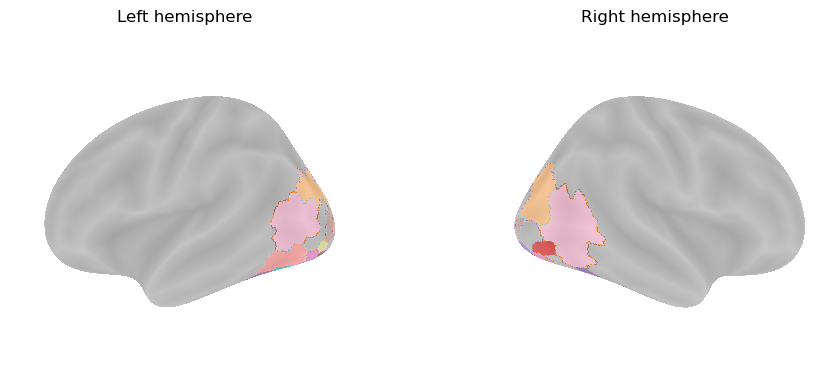

EBA            : LH=[21(100.0%), 157(95.5%), 158(100.0%), 160(91.5%), 20(97.7%), 159(88.3%), 23(90.8%), 467(80.9%), 181(95.1%), 155(59.1%), 156(77.3%)], RH=[35(96.2%), 39(97.5%), 37(100.0%), 2(100.0%), 0(99.1%), 42(87.6%), 36(90.2%), 13(93.2%), 43(98.1%), 41(96.9%), 9(81.3%), 1(64.4%), 49(96.8%), 40(89.5%), 46(56.7%), 58(69.6%), 57(71.8%), 56(82.9%)]
FBA-2          : LH=[None], RH=[4(85.8%)]
FFA-1          : LH=[151(83.2%), 6(65.3%)], RH=[None]
FFA-2          : LH=[None], RH=[147(92.1%)]
OFA            : LH=[15(55.4%)], RH=[None]
OPA            : LH=[161(100.0%), 32(76.2%), 163(100.0%), 31(62.3%), 29(94.5%), 469(89.4%), 162(71.0%), 33(71.7%), 468(90.2%)], RH=[28(100.0%), 29(93.8%), 24(69.6%), 162(68.3%), 161(89.9%), 31(81.8%), 22(91.3%), 32(73.2%), 3(94.2%), 27(64.7%), 26(98.4%), 30(80.9%)]
OWFA           : LH=[None], RH=[11(67.2%)]
PPA            : LH=[45(100.0%), 44(50.5%), 481(100.0%), 482(92.9%)], RH=[424(79.3%), 427(92.8%)]
RSC            : LH=[475(100.0%), 473(100.0%), 471(100.0%

In [27]:
plot_schaefer_by_roi_nilearn(
    dataset=train_dataset,
    metadata=metadata,
    dominant_rois=dominant_rois,
    all_roi_names=all_roi_names,
    mesh="fsaverage",   # matches your 163842/hemis split
    view="lateral"      # try 'medial','dorsal','ventral' too
)

[fetch_surf_fsaverage] Dataset found in /home/pf2477/nilearn_data/fsaverage


/tmp/ipykernel_216635/1337251920.py:49: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plotting.plot_surf(surfL, lh_labels, bg_map=bgL, hemi="left", view=view,
/tmp/ipykernel_216635/1337251920.py:55: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plotting.plot_surf(surfR, rh_labels, bg_map=bgR, hemi="right", view=view,


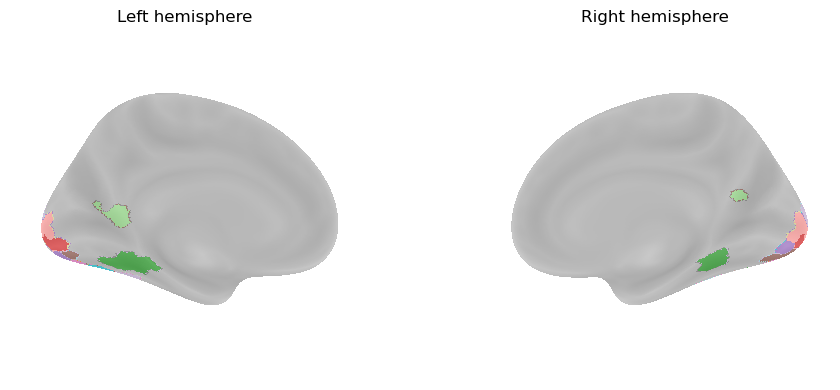

Label index → ROI
 0: (unlabeled)
 1: V1v
 2: V1d
 3: V2v
 4: V2d
 5: V3v
 6: V3d
 7: hV4
 8: EBA
 9: FBA-1
10: FBA-2
11: mTL-bodies
12: OFA
13: FFA-1
14: FFA-2
15: mTL-faces
16: aTL-faces
17: OPA
18: PPA
19: RSC
20: OWFA
21: VWFA-1
22: VWFA-2
23: mfs-words
24: mTL-words
25: V1v
26: V1d
27: V2v
28: V2d
29: V3v
30: V3d
31: hV4
32: EBA
33: FBA-1
34: FBA-2
35: mTL-bodies
36: OFA
37: FFA-1
38: FFA-2
39: mTL-faces
40: aTL-faces
41: OPA
42: PPA
43: RSC
44: OWFA
45: VWFA-1
46: VWFA-2
47: mfs-words
48: mTL-words


In [18]:
plot_schaefer_by_roi_nilearn(
    dataset=train_dataset,
    metadata=metadata,
    dominant_rois=dominant_rois,
    all_roi_names=all_roi_names,
    mesh="fsaverage",   # matches your 163842/hemis split
    view="medial"      # try 'medial','dorsal','ventral' too
)

[fetch_surf_fsaverage] Dataset found in /home/pf2477/nilearn_data/fsaverage


/tmp/ipykernel_216635/1337251920.py:49: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plotting.plot_surf(surfL, lh_labels, bg_map=bgL, hemi="left", view=view,
/tmp/ipykernel_216635/1337251920.py:55: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plotting.plot_surf(surfR, rh_labels, bg_map=bgR, hemi="right", view=view,


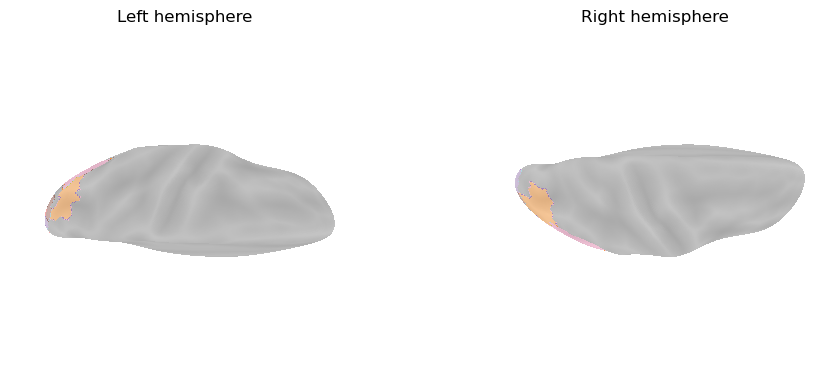

Label index → ROI
 0: (unlabeled)
 1: V1v
 2: V1d
 3: V2v
 4: V2d
 5: V3v
 6: V3d
 7: hV4
 8: EBA
 9: FBA-1
10: FBA-2
11: mTL-bodies
12: OFA
13: FFA-1
14: FFA-2
15: mTL-faces
16: aTL-faces
17: OPA
18: PPA
19: RSC
20: OWFA
21: VWFA-1
22: VWFA-2
23: mfs-words
24: mTL-words
25: V1v
26: V1d
27: V2v
28: V2d
29: V3v
30: V3d
31: hV4
32: EBA
33: FBA-1
34: FBA-2
35: mTL-bodies
36: OFA
37: FFA-1
38: FFA-2
39: mTL-faces
40: aTL-faces
41: OPA
42: PPA
43: RSC
44: OWFA
45: VWFA-1
46: VWFA-2
47: mfs-words
48: mTL-words


In [19]:
plot_schaefer_by_roi_nilearn(
    dataset=train_dataset,
    metadata=metadata,
    dominant_rois=dominant_rois,
    all_roi_names=all_roi_names,
    mesh="fsaverage",   # matches your 163842/hemis split
    view="dorsal"      # try 'medial','dorsal','ventral' too
)

[fetch_surf_fsaverage] Dataset found in /home/pf2477/nilearn_data/fsaverage


/tmp/ipykernel_216635/1337251920.py:49: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plotting.plot_surf(surfL, lh_labels, bg_map=bgL, hemi="left", view=view,
/tmp/ipykernel_216635/1337251920.py:55: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plotting.plot_surf(surfR, rh_labels, bg_map=bgR, hemi="right", view=view,


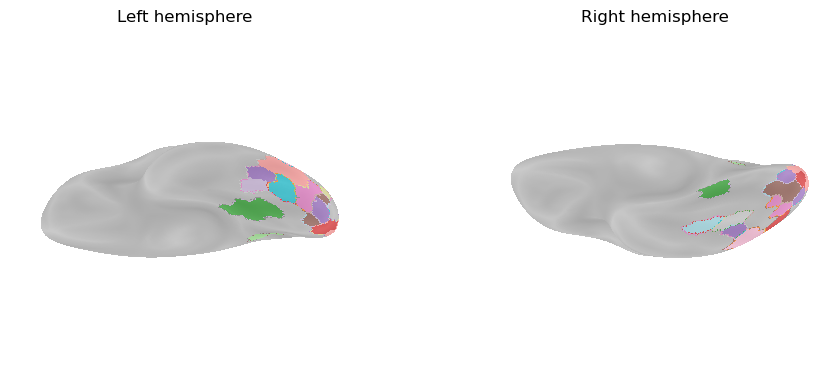

Label index → ROI
 0: (unlabeled)
 1: V1v
 2: V1d
 3: V2v
 4: V2d
 5: V3v
 6: V3d
 7: hV4
 8: EBA
 9: FBA-1
10: FBA-2
11: mTL-bodies
12: OFA
13: FFA-1
14: FFA-2
15: mTL-faces
16: aTL-faces
17: OPA
18: PPA
19: RSC
20: OWFA
21: VWFA-1
22: VWFA-2
23: mfs-words
24: mTL-words
25: V1v
26: V1d
27: V2v
28: V2d
29: V3v
30: V3d
31: hV4
32: EBA
33: FBA-1
34: FBA-2
35: mTL-bodies
36: OFA
37: FFA-1
38: FFA-2
39: mTL-faces
40: aTL-faces
41: OPA
42: PPA
43: RSC
44: OWFA
45: VWFA-1
46: VWFA-2
47: mfs-words
48: mTL-words


In [20]:
plot_schaefer_by_roi_nilearn(
    dataset=train_dataset,
    metadata=metadata,
    dominant_rois=dominant_rois,
    all_roi_names=all_roi_names,
    mesh="fsaverage",   # matches your 163842/hemis split
    view="ventral"      # try 'medial','dorsal','ventral' too
)

In [38]:
def plot_schaefer_by_roi_nilearn_multi(
    dataset, metadata, dominant_rois, all_roi_names,
    unlabeled_name="(unlabeled)", unlabeled_color=(0.7,0.7,0.7,1.0),
    mesh="fsaverage", views=("lateral","medial","dorsal","ventral"),
    darkness=0.5, figsize=(16, 6)
):
    # ROI→index (0 reserved for unlabeled)
    roi_list = [unlabeled_name] + all_roi_names
    roi_to_idx = {name: i for i, name in enumerate(roi_list)}

    # Hemisphere sizes
    lh_n = len(next(iter(metadata["lh_rois"].values())))
    rh_n = len(next(iter(metadata["rh_rois"].values())))

    # Init per-vertex label arrays
    lh_labels = np.zeros(lh_n, dtype=np.int32)
    rh_labels = np.zeros(rh_n, dtype=np.int32)

    # Parcel voxel indices (per selected parcel)
    sel_vox = dataset.get_selected_voxel_indices()

    # Paint parcels by dominant ROI label
    for hemi, labels, dom in [("lh", lh_labels, dominant_rois["lh"]),
                              ("rh", rh_labels, dominant_rois["rh"])]:
        for pos, (_orig_idx, roi_name, _overlap, _nvox) in enumerate(dom):
            vox = sel_vox[hemi][pos]
            vox = vox.cpu().numpy() if isinstance(vox, torch.Tensor) else np.asarray(vox)
            if vox.size == 0: 
                continue
            labels[vox] = roi_to_idx.get(roi_name, 0) if roi_name is not None else 0

    # Discrete colormap (0=unlabeled gray)
    base = plt.cm.tab20(np.linspace(0, 1, 20))
    need = max(1, len(roi_list) - 1)
    palette = np.vstack([base[1:],] * int(np.ceil(need / 19)))[:need]
    cmap = ListedColormap(np.vstack([np.array(unlabeled_color)[None, :], palette]))
    norm = Normalize(vmin=0, vmax=len(roi_list)-1)

    # Load fsaverage surfaces
    fsavg = datasets.fetch_surf_fsaverage(mesh=mesh)
    surfL, bgL = (fsavg.infl_left, fsavg.sulc_left) if hasattr(fsavg, "infl_left") else (fsavg.pial_left, fsavg.sulc_left)
    surfR, bgR = (fsavg.infl_right, fsavg.sulc_right) if hasattr(fsavg, "infl_right") else (fsavg.pial_right, fsavg.sulc_right)

    # Figure with LH (row 0) and RH (row 1) across views (columns)
    ncols = len(views)
    fig = plt.figure(figsize=figsize)
    axes = []
    for r in range(2):
        for c, view in enumerate(views):
            ax = fig.add_subplot(2, ncols, r*ncols + c + 1, projection="3d")
            axes.append(ax)
            if r == 0:
                # Left hemi
                plotting.plot_surf(
                    surfL, lh_labels, bg_map=bgL, hemi="left", view=view,
                    cmap=cmap, vmin=0, vmax=len(roi_list)-1,
                    bg_on_data=True, darkness=darkness, colorbar=False, axes=ax
                )
                ax.set_title(f"LH • {view}")
            else:
                # Right hemi
                plotting.plot_surf(
                    surfR, rh_labels, bg_map=bgR, hemi="right", view=view,
                    cmap=cmap, vmin=0, vmax=len(roi_list)-1,
                    bg_on_data=True, darkness=darkness, colorbar=False, axes=ax
                )
                ax.set_title(f"RH • {view}")

    plt.tight_layout()

    # One shared discrete colorbar
    mappable = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    cbar = fig.colorbar(mappable, ax=axes, fraction=0.02, pad=0.01)
    cbar.set_label("ROI index (0 = unlabeled)")
    plt.show()

    # Optional: print legend mapping indices → ROI names
    print("Index → ROI name")
    for i, name in enumerate(roi_list):
        print(f"{i:2d}: {name}")

[fetch_surf_fsaverage] Dataset found in /home/pf2477/nilearn_data/fsaverage


/tmp/ipykernel_216635/3428727500.py:54: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plotting.plot_surf(
/tmp/ipykernel_216635/3428727500.py:62: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plotting.plot_surf(


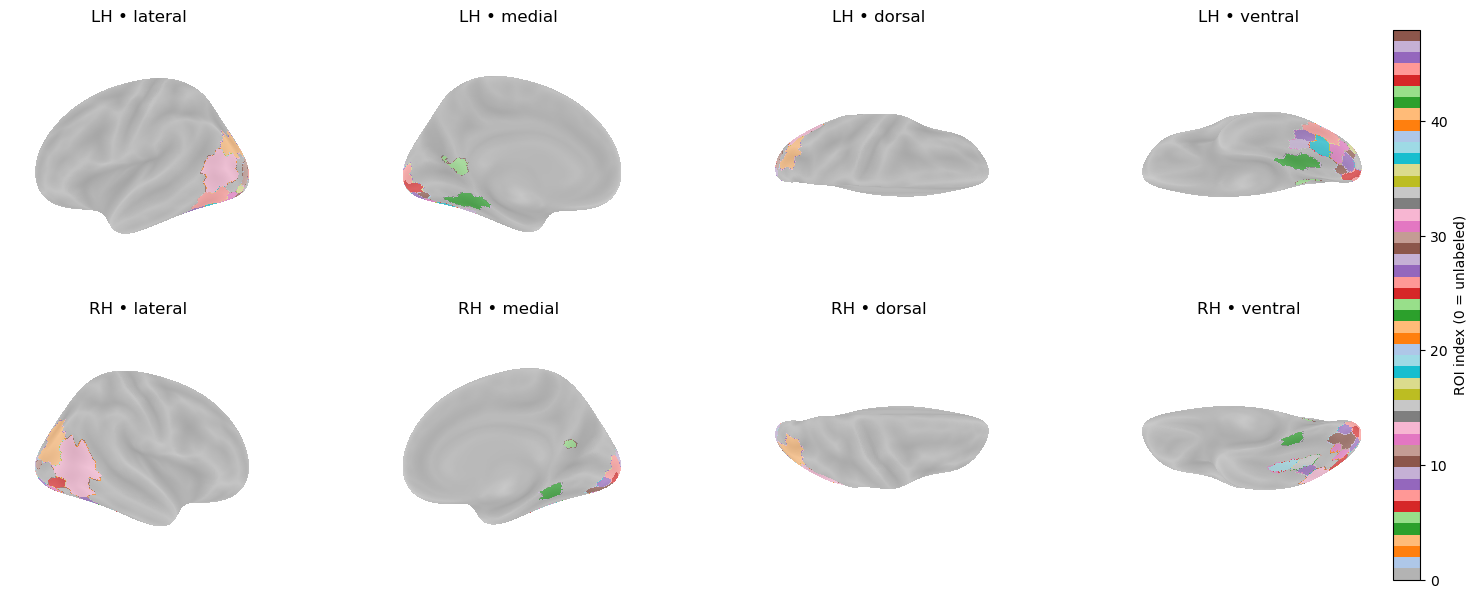

Index → ROI name
 0: (unlabeled)
 1: V1v
 2: V1d
 3: V2v
 4: V2d
 5: V3v
 6: V3d
 7: hV4
 8: EBA
 9: FBA-1
10: FBA-2
11: mTL-bodies
12: OFA
13: FFA-1
14: FFA-2
15: mTL-faces
16: aTL-faces
17: OPA
18: PPA
19: RSC
20: OWFA
21: VWFA-1
22: VWFA-2
23: mfs-words
24: mTL-words
25: V1v
26: V1d
27: V2v
28: V2d
29: V3v
30: V3d
31: hV4
32: EBA
33: FBA-1
34: FBA-2
35: mTL-bodies
36: OFA
37: FFA-1
38: FFA-2
39: mTL-faces
40: aTL-faces
41: OPA
42: PPA
43: RSC
44: OWFA
45: VWFA-1
46: VWFA-2
47: mfs-words
48: mTL-words


In [39]:
plot_schaefer_by_roi_nilearn_multi(
    dataset=train_dataset,
    metadata=metadata,
    dominant_rois=dominant_rois,
    all_roi_names=all_roi_names,
    views=("lateral","medial","dorsal","ventral")
)

In [8]:
def plot_schaefer_by_roi_nilearn_multi(
    dataset, metadata, dominant_rois, all_roi_names,
    unlabeled_name="(unlabeled)", unlabeled_color=(0.7,0.7,0.7,1.0),
    mesh="fsaverage", views=("lateral","medial","dorsal","ventral"),
    darkness=0.5, figsize=(16, 6), legend_cols=2
):
    # ROI→index (0 reserved for unlabeled)
    roi_list = [unlabeled_name] + all_roi_names
    roi_to_idx = {name: i for i, name in enumerate(roi_list)}

    # Hemisphere sizes
    lh_n = len(next(iter(metadata["lh_rois"].values())))
    rh_n = len(next(iter(metadata["rh_rois"].values())))

    # Init per-vertex label arrays
    lh_labels = np.zeros(lh_n, dtype=np.int32)
    rh_labels = np.zeros(rh_n, dtype=np.int32)

    # Parcel voxel indices (per selected parcel)
    sel_vox = dataset.get_selected_voxel_indices()

    # Paint parcels by dominant ROI label
    for hemi, labels, dom in [("lh", lh_labels, dominant_rois["lh"]),
                              ("rh", rh_labels, dominant_rois["rh"])]:
        for pos, (_orig_idx, roi_name, _overlap, _nvox) in enumerate(dom):
            vox = sel_vox[hemi][pos]
            vox = vox.cpu().numpy() if isinstance(vox, torch.Tensor) else np.asarray(vox)
            if vox.size == 0: 
                continue
            labels[vox] = roi_to_idx.get(roi_name, 0) if roi_name is not None else 0

    # Discrete colormap (0=unlabeled gray)
    base = plt.cm.tab20(np.linspace(0, 1, 20))
    need = max(1, len(roi_list) - 1)
    palette = np.vstack([base[1:],] * int(np.ceil(need / 19)))[:need]
    cmap = ListedColormap(np.vstack([np.array(unlabeled_color)[None, :], palette]))

    # Load fsaverage surfaces
    fsavg = datasets.fetch_surf_fsaverage(mesh=mesh)
    surfL, bgL = (fsavg.infl_left, fsavg.sulc_left) if hasattr(fsavg, "infl_left") else (fsavg.pial_left, fsavg.sulc_left)
    surfR, bgR = (fsavg.infl_right, fsavg.sulc_right) if hasattr(fsavg, "infl_right") else (fsavg.pial_right, fsavg.sulc_right)

    # Figure with LH (row 0) and RH (row 1) across views (columns)
    ncols = len(views)
    fig = plt.figure(figsize=figsize)
    axes = []
    for r in range(2):
        for c, view in enumerate(views):
            ax = fig.add_subplot(2, ncols, r*ncols + c + 1, projection="3d")
            axes.append(ax)
            if r == 0:
                plotting.plot_surf(
                    surfL, lh_labels, bg_map=bgL, hemi="left", view=view,
                    cmap=cmap, vmin=0, vmax=len(roi_list)-1,
                    bg_on_data=True, darkness=darkness, colorbar=False, axes=ax
                )
                ax.set_title(f"LH • {view}")
            else:
                plotting.plot_surf(
                    surfR, rh_labels, bg_map=bgR, hemi="right", view=view,
                    cmap=cmap, vmin=0, vmax=len(roi_list)-1,
                    bg_on_data=True, darkness=darkness, colorbar=False, axes=ax
                )
                ax.set_title(f"RH • {view}")

    plt.tight_layout()

    # Find which ROIs are actually used in the mapping
    used_rois = set([unlabeled_name])  # Always include unlabeled
    for hemi in ['lh', 'rh']:
        for _, roi_name, _, _ in dominant_rois[hemi]:
            if roi_name is not None:
                used_rois.add(roi_name)
    
    # Create legend patches only for used ROIs
    bar_patches = []
    for roi_name in sorted(used_rois):
        if roi_name in roi_to_idx:
            idx = roi_to_idx[roi_name]
            bar_patches.append(Patch(color=cmap(idx), label=roi_name))

    # Place legend below the plots
    fig.legend(
        handles=bar_patches, loc="lower center", ncol=legend_cols,
        fontsize="small", frameon=False, bbox_to_anchor=(0.5, -0.02)
    )

    plt.subplots_adjust(bottom=0.18)  # Make space for legend
    plt.show()
    
    print(f"Legend shows {len(bar_patches)} entries: {len(bar_patches)-1} mapped ROIs + unlabeled")

[fetch_surf_fsaverage] Dataset found in /home/pf2477/nilearn_data/fsaverage


/tmp/ipykernel_51216/676214691.py:52: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plotting.plot_surf(
/tmp/ipykernel_51216/676214691.py:59: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plotting.plot_surf(
/tmp/ipykernel_51216/676214691.py:59: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plotting.plot_surf(


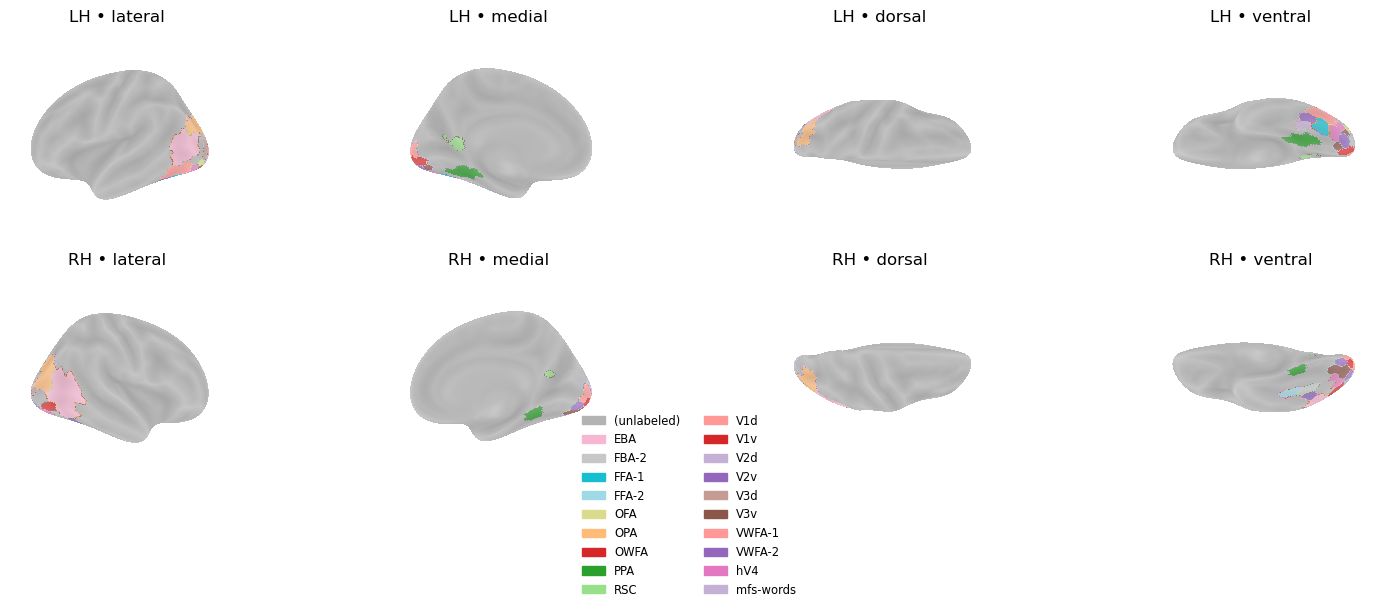

Legend shows 20 entries: 19 mapped ROIs + unlabeled


In [9]:
plot_schaefer_by_roi_nilearn_multi(
    dataset=train_dataset,
    metadata=metadata,
    dominant_rois=dominant_rois,
    all_roi_names=all_roi_names,
    views=("lateral","medial","dorsal","ventral")
)